# 🧪 LAB 4B — Polynomial Regression (Temperature vs Power Demand)
### Bologna Business School — Machine Learning Lab

**Dataset:** `power_demand_vs_temperature.csv`

## 🎯 Objectives
- Load and inspect the dataset
- Build a baseline linear regression model
- Fit polynomial regression models (degrees 2, 3, 4)
- Evaluate models using RMSE and R² (plus F-statistic and p-value)
- Visualise fitted curves and discuss overfitting risk

---

In [1]:
# 🛠️ Environment setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.linear_model import LinearRegression 
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

random_state = 42
np.random.seed(random_state)

## 1️⃣ Load the dataset
We load the CSV and set the date as the index (time information is not directly used for regression here).

In [2]:
df_temp = pd.read_csv("power_demand_vs_temperature.csv", parse_dates=["date"])
df_temp.set_index("date", inplace=True)
df_temp.head()

,demand,temp
date,,
2015-01-01,1.736065,1.7
2015-01-02,1.831672,2.2
2015-01-03,1.714934,14.4
2015-01-04,1.628577,15.6
2015-01-05,2.045394,0.0


## 2️⃣ Inspect the data
We check summary statistics and confirm there are no missing values.

In [3]:
display(df_temp.describe())
print("\nMissing values:")
display(df_temp.isna().sum())

,demand,temp
count,1096.000000,1096.000000
mean,1.831796,16.927737
std,0.329434,10.791581
min,1.316033,-15.000000
25%,1.581654,8.900000
50%,1.731479,18.900000
75%,2.024869,26.100000
max,2.804025,33.900000



Missing values:


demand    0
temp      0
dtype: int64

## 3️⃣ Define features (X) and target (y)
- Feature: `temp`
- Target: `demand`

In [4]:
X2 = df_temp[["temp"]].values
y2 = df_temp["demand"].values

print("X shape:", X2.shape)
print("y shape:", y2.shape)

X shape: (1096, 1)
y shape: (1096,)


## 4️⃣ Train/test split

In [5]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.3, random_state=random_state
)

print("Training samples:", X2_train.shape[0])
print("Test samples:", X2_test.shape[0])

Training samples: 767
Test samples: 329


## 5️⃣ Evaluation function
We compute RMSE and R², and also report an F-statistic and p-value for educational purposes.

**Interpretation note:** The classical F-test relies on linear-model assumptions. Polynomial regression is linear in parameters, so it fits within the same framework, but results should still be interpreted cautiously in real applications.

In [6]:
def evaluate_model(y_true, y_pred, X_design):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred)) #Measures average prediction error
    r2 = r2_score(y_true, y_pred) #Measures how much variance is explained

    n = len(y_true)
    p = X_design.shape[1]

    # Guard against division by zero when R² ~ 1
    denom = (1 - r2) / max(n - p - 1, 1)
    f_stat = (r2 / max(p, 1)) / denom if denom > 0 else np.inf
    p_value = 1 - stats.f.cdf(f_stat, p, max(n - p - 1, 1)) if np.isfinite(f_stat) else 0.0

    return rmse, r2, f_stat, p_value

---
## 6️⃣ Experiment 1 — Linear regression
We start with a linear model and observe its limitations when the relationship is clearly non-linear.

In [7]:
lin = LinearRegression()
lin.fit(X2_train, y2_train)

y2_pred_lin = lin.predict(X2_test)
rmse_lin, r2_lin, f_lin, p_lin = evaluate_model(y2_test, y2_pred_lin, X2_test)

print("Linear regression")
print("RMSE:", rmse_lin)
print("R²:", r2_lin)
print("F-statistic:", f_lin)
print("p-value:", p_lin)

Linear regression
RMSE: 0.31882728059413395
R²: 0.16809034828105496
F-statistic: 66.07153045325492
p-value: 9.103828801926284e-15


---
## 7️⃣ Polynomial regression (degrees 2, 3, 4)
We expand the feature space using polynomial features and fit linear regression in the expanded space.

In [8]:
results = []
models_poly = {}

for degree in [2, 3, 4]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)

    X2_train_poly = poly.fit_transform(X2_train)
    X2_test_poly = poly.transform(X2_test)

    model = LinearRegression()
    model.fit(X2_train_poly, y2_train)

    y2_pred = model.predict(X2_test_poly)
    rmse, r2, f_stat, p_value = evaluate_model(y2_test, y2_pred, X2_test_poly)

    results.append((degree, rmse, r2, f_stat, p_value))
    models_poly[degree] = (poly, model)

poly_comparison = pd.DataFrame(
    results,
    columns=["Degree", "RMSE", "R²", "F-statistic", "p-value"]
)

poly_comparison

,Degree,RMSE,R²,F-statistic,p-value
0,2,0.182910,0.726194,432.312675,1.110223e-16
1,3,0.147477,0.822003,500.290945,1.110223e-16
2,4,0.146061,0.825404,382.927456,1.110223e-16


## 8️⃣ Visualise fitted curves
We plot the data and the fitted curves for linear and polynomial models. This provides an intuitive understanding of why polynomial regression improves performance here.

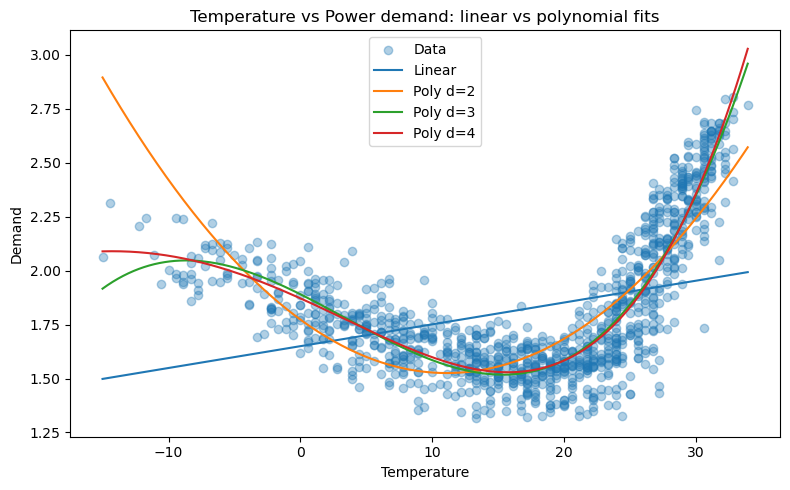

In [9]:
x_grid = np.linspace(X2.min(), X2.max(), 500).reshape(-1, 1)

plt.figure(figsize=(8, 5))
plt.scatter(X2, y2, alpha=0.35, label="Data")

# Linear curve
plt.plot(x_grid, lin.predict(x_grid), label="Linear")

# Polynomial curves
for degree in [2, 3, 4]:
    poly, model = models_poly[degree]
    xg_poly = poly.transform(x_grid)
    plt.plot(x_grid, model.predict(xg_poly), label=f"Poly d={degree}")

plt.title("Temperature vs Power demand: linear vs polynomial fits")
plt.xlabel("Temperature")
plt.ylabel("Demand")
plt.legend()
plt.tight_layout()
plt.show()

---
# 🧠 Final observations
- Linear regression performs well only if the relationship is approximately linear.
- In the marketing dataset, one feature often dominates (identified via correlation/coefficients).
- Tree-based models capture non-linear interactions but can overfit; cross-validation helps select complexity.
- Polynomial regression can model curved relationships effectively, but higher degrees may overfit.

## ❓ Control questions (submit short answers)
1. Which feature is the strongest predictor in the marketing dataset? How did you decide?
2. Compare univariate vs multivariate linear regression: when does adding features help or hurt?
3. Why does tuning `max_depth` affect overfitting in a decision tree?
4. Why do polynomial models improve the temperature–demand fit? What are the risks of high degrees?

## 📦 Deliverables
Submit:
- The cleaned dataset size and the number of removed rows
- The correlation ranking vs the target
- The model comparison table (RMSE and R²)
- The fitted-curve plot for polynomial regression
- Answers to the control questions
